In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clinical_gex = pd.read_csv(f"../dataset/created/clinical_gex/clinical_gex.csv")
clinical_gex

/var/folders/cy/vstztct90b90zhd8ssbmwpgh0000gn/T/ipykernel_14684/923533292.py:5: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical_gex = pd.read_csv(f"../dataset/created/clinical_gex/clinical_gex.csv")


,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_status,PFS_month,drug,BOR,...,FER,DCLK1,CENPL,FZD1,UBE2A,FBN2,KIAA1586,CLIC5,HAUS6,MIRLET7D
0,YR_3053,male,26,IV,M1B,elevated,1.0,2.9,vemurafenib,PD,...,4.848412,5.765024,5.405917,5.576334,6.995104,4.997314,4.600878,3.988906,4.463209,4.004989
1,YR_3708,female,58,IV,M1A,normal,0.0,13.2,vemurafenib,CR,...,5.229689,5.921719,5.427977,5.617456,7.314188,4.965099,4.659288,3.988537,4.603643,4.324637
2,YR_3705,male,45,IV,M1A,normal,0.0,17.4,vemurafenib,CR,...,5.188426,5.713174,5.427922,5.515963,7.185057,5.426698,5.028254,3.996558,4.800874,4.348986
3,YR_1106,male,48,IIIC,NaN,normal,1.0,1.4,vemurafenib + cobimetinib,PD,...,4.883034,5.817023,5.396312,5.722212,6.983151,5.478849,4.623254,3.996295,4.441287,4.777784
4,YR_1110,male,33,IV,M1C,normal,1.0,1.4,vemurafenib + cobimetinib,PD,...,5.025112,6.090802,5.392477,5.643715,7.197660,4.979833,4.879302,4.011350,4.533517,5.500480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,KC_19,male,62,IV,NaN,NaN,1.0,16.6,dabrafenib + trametinib,PR,...,5.138625,5.573702,5.241205,5.222764,6.730318,5.146068,4.676080,3.966343,4.413339,4.590374
121,KC_22,male,49,IV,NaN,NaN,1.0,2.8,dabrafenib + trametinib,PR,...,5.276458,5.839700,5.704260,5.744767,7.545910,5.170947,5.185139,4.032988,4.879651,4.590374
122,KC_24,female,68,IV,NaN,NaN,1.0,4.7,vemurafenib,PR,...,5.172261,5.778458,5.653966,6.069914,7.416537,5.153769,4.964024,4.149259,4.899236,4.590374
123,KC_25,male,72,IV,NaN,NaN,1.0,3.4,dabrafenib + trametinib,PR,...,5.275684,6.478791,5.584304,5.629770,7.046463,5.169998,4.863169,4.027474,4.765802,4.590374


In [101]:
LONG_RESP_THRESHOLD = 12

In [102]:
def get_pfs_label(row):
    months = row['PFS_month']
    event = row['PFS_status']
    
    if months >= LONG_RESP_THRESHOLD:
        return 2  # Long responder
    elif months < 6 and event == 1:
        return 0   # Non responder
    elif 6 <= months < LONG_RESP_THRESHOLD and event == 1:
        return 1 # Intermediate
    # else:
    #     return np.nan   # Undetermind
    # Censored cases - assign based on lower bound
    elif months < 6 and event == 0:
        return 0  # Conservative: assume non-responder (survived AT LEAST x months)
    elif 6 <= months < LONG_RESP_THRESHOLD and event == 0:
        return 1  # Conservative: assume intermediate
    
clinical_gex['pfs_label'] = clinical_gex.apply(get_pfs_label, axis=1)

# clinical_gex = clinical_gex.drop(['PFS_status', 'PFS_month'], axis=1)
clinical_gex.iloc[:, :10]

,patientID,sex,age,AJCC_stage,M_stage,LDH,PFS_status,PFS_month,drug,BOR
0,YR_3053,male,26,IV,M1B,elevated,1.0,2.9,vemurafenib,PD
1,YR_3708,female,58,IV,M1A,normal,0.0,13.2,vemurafenib,CR
2,YR_3705,male,45,IV,M1A,normal,0.0,17.4,vemurafenib,CR
3,YR_1106,male,48,IIIC,NaN,normal,1.0,1.4,vemurafenib + cobimetinib,PD
4,YR_1110,male,33,IV,M1C,normal,1.0,1.4,vemurafenib + cobimetinib,PD
...,...,...,...,...,...,...,...,...,...,...
120,KC_19,male,62,IV,NaN,NaN,1.0,16.6,dabrafenib + trametinib,PR
121,KC_22,male,49,IV,NaN,NaN,1.0,2.8,dabrafenib + trametinib,PR
122,KC_24,female,68,IV,NaN,NaN,1.0,4.7,vemurafenib,PR
123,KC_25,male,72,IV,NaN,NaN,1.0,3.4,dabrafenib + trametinib,PR


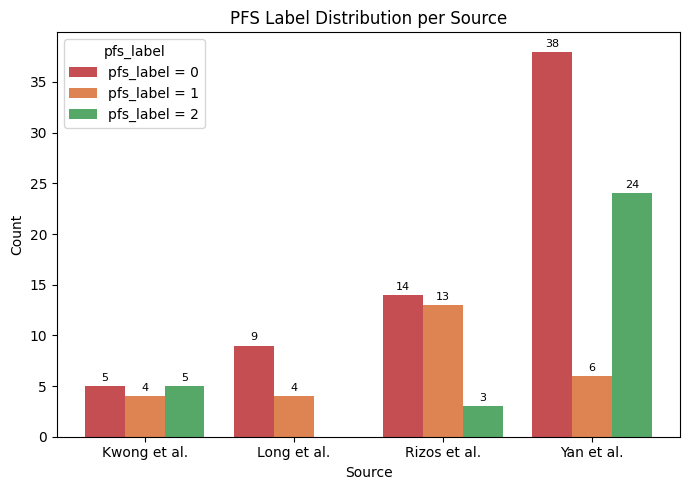

In [107]:
plot_df = clinical_gex.copy()
plot_df['pfs_label'] = plot_df['pfs_label'].apply(
    lambda x: 'NaN' if pd.isna(x) else str(int(x))
)

counts = plot_df.groupby(['source', 'pfs_label']).size().unstack(fill_value=0)

x = np.arange(len(counts.index))
width = 0.8 / len(counts.columns)
labels = counts.columns.tolist()
colors = ['#C44E52', '#DD8452', '#55A868']
# colors = ['#C44E52', '#55A868', '#808080']

fig, ax = plt.subplots(figsize=(7, 5))
for i, (label, color) in enumerate(zip(labels, colors)):
    bars = ax.bar(x + i * width, counts[label], width, label=f'pfs_label = {label}', color=color)
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3,
                    str(int(height)), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width * (len(labels) - 1) / 2)
ax.set_xticklabels(counts.index)
ax.set_xlabel('Source')
ax.set_ylabel('Count')
ax.set_title('PFS Label Distribution per Source')
ax.legend(title='pfs_label')
plt.tight_layout()
plt.show()


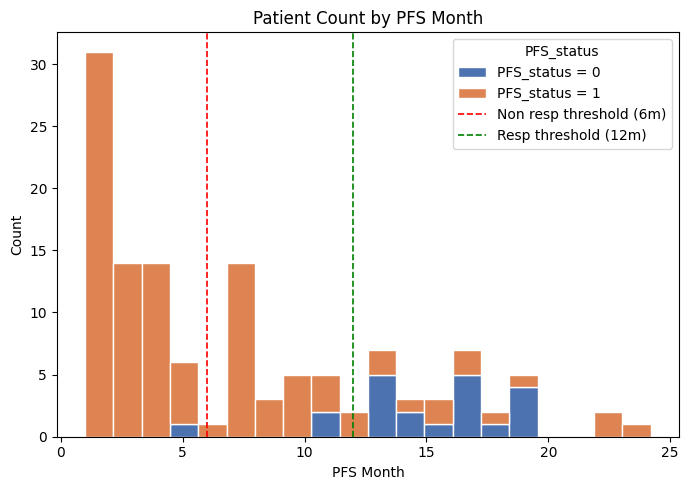

In [104]:
import matplotlib.pyplot as plt
import numpy as np

pfs_df = clinical_gex[clinical_gex['PFS_month'].notna() & clinical_gex['PFS_status'].notna()].copy()
bins = np.linspace(pfs_df['PFS_month'].min(), pfs_df['PFS_month'].max(), 21)

status_values = sorted(pfs_df['PFS_status'].unique())
colors = ['#4C72B0', '#DD8452']

fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.hist(
    [pfs_df[pfs_df['PFS_status'] == s]['PFS_month'] for s in status_values],
    bins=bins,
    stacked=True,
    color=colors,
    edgecolor='white',
    label=[f'PFS_status = {int(s)}' for s in status_values]
)
ax2.set_xlabel('PFS Month')
ax2.set_ylabel('Count')
ax2.set_title('Patient Count by PFS Month')
ax2.axvline(x=6, color='red', linestyle='--', linewidth=1.2, label='Non resp threshold (6m)')
ax2.axvline(x=LONG_RESP_THRESHOLD, color='green', linestyle='--', linewidth=1.2, label=f'Resp threshold ({LONG_RESP_THRESHOLD}m)')
ax2.legend(title='PFS_status')
plt.tight_layout()
plt.show()


In [105]:
clinical_gex = clinical_gex.drop(['PFS_status', 'PFS_month'], axis=1)
clinical_gex

,patientID,sex,age,AJCC_stage,M_stage,LDH,drug,BOR,BRAF_mut,brain_metastasis,...,DCLK1,CENPL,FZD1,UBE2A,FBN2,KIAA1586,CLIC5,HAUS6,MIRLET7D,pfs_label
0,YR_3053,male,26,IV,M1B,elevated,vemurafenib,PD,V600E,NaN,...,5.765024,5.405917,5.576334,6.995104,4.997314,4.600878,3.988906,4.463209,4.004989,0
1,YR_3708,female,58,IV,M1A,normal,vemurafenib,CR,V600E,NaN,...,5.921719,5.427977,5.617456,7.314188,4.965099,4.659288,3.988537,4.603643,4.324637,2
2,YR_3705,male,45,IV,M1A,normal,vemurafenib,CR,V600E,NaN,...,5.713174,5.427922,5.515963,7.185057,5.426698,5.028254,3.996558,4.800874,4.348986,2
3,YR_1106,male,48,IIIC,NaN,normal,vemurafenib + cobimetinib,PD,V600E,NaN,...,5.817023,5.396312,5.722212,6.983151,5.478849,4.623254,3.996295,4.441287,4.777784,0
4,YR_1110,male,33,IV,M1C,normal,vemurafenib + cobimetinib,PD,V600E,NaN,...,6.090802,5.392477,5.643715,7.197660,4.979833,4.879302,4.011350,4.533517,5.500480,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,KC_19,male,62,IV,NaN,NaN,dabrafenib + trametinib,PR,V600E,yes,...,5.573702,5.241205,5.222764,6.730318,5.146068,4.676080,3.966343,4.413339,4.590374,2
121,KC_22,male,49,IV,NaN,NaN,dabrafenib + trametinib,PR,V600K,no,...,5.839700,5.704260,5.744767,7.545910,5.170947,5.185139,4.032988,4.879651,4.590374,0
122,KC_24,female,68,IV,NaN,NaN,vemurafenib,PR,V600K,yes,...,5.778458,5.653966,6.069914,7.416537,5.153769,4.964024,4.149259,4.899236,4.590374,0
123,KC_25,male,72,IV,NaN,NaN,dabrafenib + trametinib,PR,V600K,no,...,6.478791,5.584304,5.629770,7.046463,5.169998,4.863169,4.027474,4.765802,4.590374,0


In [106]:
clinical_gex.to_csv(f"../dataset/created/clinical_gex/clinical_gex_w_target.csv")